In [26]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

## Buscamos excel que arma alertas

In [ ]:
df = pd.read_excel('Ejercicio_1_datos_y_etiquetas_excel_en_drive.xlsm', sheet_name="Datos", header=1)
df.head()

,firm_id,firm_name,sector,reporting_period,revenue_reported_mm,revenue_growth_pct,operating_expenses_reported_mm,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,...,MAINTENANCE CAPEX SHARE P10,Exceso Gap ratio >90,P75 NPL growth,P25 Coverage change,P25 Credit loss coverage,P10 debt end ratio,Alert intensity Flag 1,Alert intensity Flag 2,Alert intensity Flag 3,Score
0,F0902,Empresa Sintética 0902,Consumer,FY2025,450.106957,0.096128,352.612135,97.494822,0.000401,71.418682,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
1,F0433,Empresa Sintética 0433,Technology,FY2025,191.003698,-0.008027,132.745985,58.257713,0.008613,38.250478,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
2,F0060,Empresa Sintética 0060,Energy,FY2025,212.581800,-0.039645,153.417378,59.164422,0.012086,48.388364,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
3,F0257,Empresa Sintética 0257,Financials,FY2025,206.763230,0.012685,139.493884,67.269346,0.002958,39.379762,...,0.0,0.394825,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
4,F0057,Empresa Sintética 0057,Energy,FY2025,96.633886,0.041338,72.479557,24.154329,0.002733,20.172502,...,0.0,0.000000,0.0,0.0,0.0,0.045538,0.0,0.0,0.0,0.045538


In [ ]:
df = df.rename(columns={'Flag World com = Señal de capitalización de gastos': 'Flag WorldCom'})

## Distribucion Score

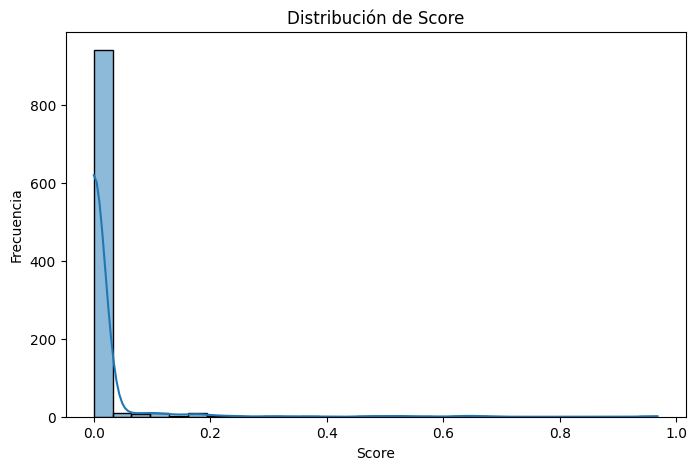

In [9]:


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Score', bins=30, kde=True)

plt.title('Distribución de Score')
plt.xlabel('Score')
plt.ylabel('Frecuencia')
plt.show()

## 

In [13]:
columnas_flags = [columna for columna in df.columns if columna.startswith("Flag")]
cantidad_por_flag = (
    df[columnas_flags]
    .eq(1)
    .sum()
    .rename("cantidad_empresas")
    .to_frame()
)
cantidad_por_flag

,cantidad_empresas
Flag WorldCom,11
Flag Linn energy,13
Flag New Century,9
Flag Lehman,50


## Seleccionamos 25 empresas mas prioritarias

In [15]:
nombres_flags = {
    'Flag WorldCom': 'WorldCom',
    'Flag Linn energy': 'Linn',
    'Flag New Century': 'New Century',
    'Flag Lehman': 'Lehman'
}
## seleccionamos las 25 mas importantes
top_25 = df.sort_values('Score', ascending=False).head(25).copy()

def buscar_señales(fila):
    señales = []

    for columna, nombre in nombres_flags.items():
        if fila[columna] == 1:
            señales.append(nombre)

    return ', '.join(señales)

top_25['Señales activadas'] = top_25.apply(buscar_señales, axis=1)

top_25[['firm_id', 'sector', 'Score', 'Señales activadas']].round(3)

,firm_id,sector,Score,Señales activadas
681,F0968,Consumer,0.967,Linn
398,F0210,Financials,0.956,New Century
300,F0316,Financials,0.671,New Century
94,F0338,Financials,0.644,New Century
214,F0232,Financials,0.639,New Century
690,F0022,Energy,0.633,Linn
536,F0367,Financials,0.577,New Century
473,F0857,Consumer,0.531,Linn
685,F0237,Financials,0.517,WorldCom
860,F0076,Energy,0.514,Linn


In [16]:
columnas_flags = [columna for columna in top_25.columns if columna.startswith("Flag")]
cantidad_por_flag = (
    top_25[columnas_flags]
    .eq(1)
    .sum()
    .rename("cantidad_empresas")
    .to_frame()
)
cantidad_por_flag

,cantidad_empresas
Flag WorldCom,5
Flag Linn energy,9
Flag New Century,8
Flag Lehman,4


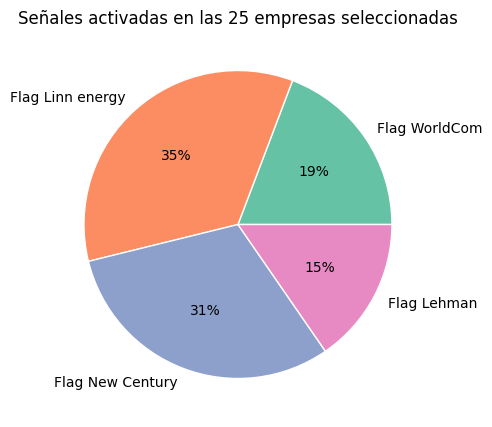

In [18]:
colores = sns.color_palette('Set2', 4)

cantidad_por_flag['cantidad_empresas'].plot.pie(
    autopct='%1.0f%%',
    ylabel='',
    figsize=(5, 5),
    colors=colores,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Señales activadas en las 25 empresas seleccionadas')
plt.show()

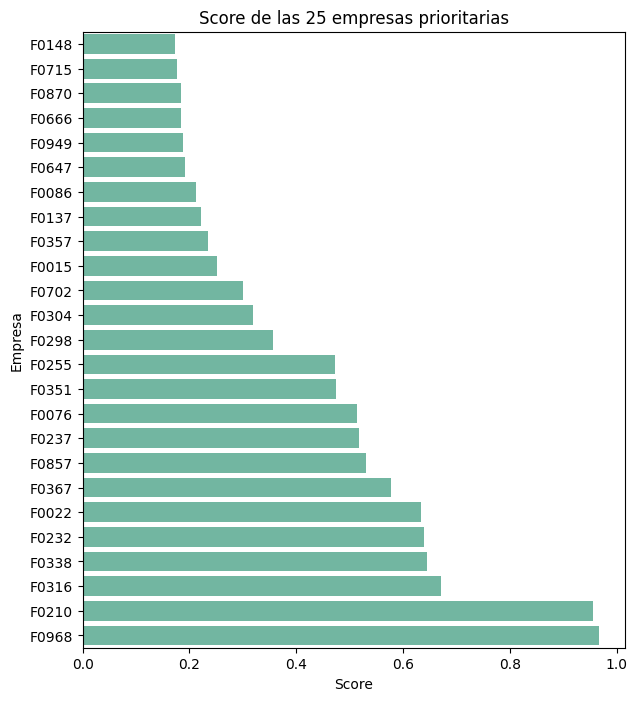

In [19]:
top_25_ordenado = top_25.sort_values('Score')

plt.figure(figsize=(7, 8))

sns.barplot(
    data=top_25_ordenado,
    x='Score',
    y='firm_id',
    color='#66c2a5'
)

plt.title('Score de las 25 empresas prioritarias')
plt.xlabel('Score')
plt.ylabel('Empresa')
plt.show()

In [24]:
##armo un flag de las 25 empresas prioritarias para poder evaluar la predicción del modelo.
df['flag_top_25'] = df['firm_id'].isin(top_25['firm_id']).astype(int)

df['flag_top_25'].value_counts()

flag_top_25
0    975
1     25
Name: count, dtype: int64

## Analisis con las etiquetas

In [25]:
## Bajamos las etiquetas de la hoja "Etiquetas - usar al final" y hacemos un merge con el df original para poder evaluar la predicción del modelo.
etiquetas = pd.read_excel(
    'Ejercicio_1_datos_y_etiquetas_excel_en_drive.xlsm',
    sheet_name="Etiquetas - usar al final",
    header=2,
)

df_evaluacion = df.merge(
    etiquetas,
    on="firm_id",
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert df_evaluacion["_merge"].eq("both").all(), "Hay empresas sin etiqueta."
df_evaluacion = df_evaluacion.drop(columns="_merge")
df_evaluacion.head()

,firm_id,firm_name,sector,reporting_period,revenue_reported_mm,revenue_growth_pct,operating_expenses_reported_mm,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,...,P25 Credit loss coverage,P10 debt end ratio,Alert intensity Flag 1,Alert intensity Flag 2,Alert intensity Flag 3,Score,flag_top_25,is_manipulated,shenanigan_type,shenanigan_name
0,F0902,Empresa Sintética 0902,Consumer,FY2025,450.106957,0.096128,352.612135,97.494822,0.000401,71.418682,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
1,F0433,Empresa Sintética 0433,Technology,FY2025,191.003698,-0.008027,132.745985,58.257713,0.008613,38.250478,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
2,F0060,Empresa Sintética 0060,Energy,FY2025,212.581800,-0.039645,153.417378,59.164422,0.012086,48.388364,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
3,F0257,Empresa Sintética 0257,Financials,FY2025,206.763230,0.012685,139.493884,67.269346,0.002958,39.379762,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
4,F0057,Empresa Sintética 0057,Energy,FY2025,96.633886,0.041338,72.479557,24.154329,0.002733,20.172502,...,0.0,0.045538,0.0,0.0,0.0,0.045538,0,1,4,quarter_end_window_dressing


In [39]:
df_evaluacion

,firm_id,firm_name,sector,reporting_period,revenue_reported_mm,revenue_growth_pct,operating_expenses_reported_mm,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,...,P25 Credit loss coverage,P10 debt end ratio,Alert intensity Flag 1,Alert intensity Flag 2,Alert intensity Flag 3,Score,flag_top_25,is_manipulated,shenanigan_type,shenanigan_name
0,F0902,Empresa Sintética 0902,Consumer,FY2025,450.106957,0.096128,352.612135,97.494822,0.000401,71.418682,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
1,F0433,Empresa Sintética 0433,Technology,FY2025,191.003698,-0.008027,132.745985,58.257713,0.008613,38.250478,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
2,F0060,Empresa Sintética 0060,Energy,FY2025,212.581800,-0.039645,153.417378,59.164422,0.012086,48.388364,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
3,F0257,Empresa Sintética 0257,Financials,FY2025,206.763230,0.012685,139.493884,67.269346,0.002958,39.379762,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
4,F0057,Empresa Sintética 0057,Energy,FY2025,96.633886,0.041338,72.479557,24.154329,0.002733,20.172502,...,0.0,0.045538,0.0,0.0,0.0,0.045538,0,1,4,quarter_end_window_dressing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,F0276,Empresa Sintética 0276,Financials,FY2025,166.911510,0.041387,119.902319,47.009191,-0.001184,37.204512,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
996,F0313,Empresa Sintética 0313,Financials,FY2025,319.244078,0.052539,224.980915,94.263163,-0.012830,64.027712,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
997,F0117,Empresa Sintética 0117,Energy,FY2025,183.586700,0.001782,138.868528,44.718171,0.009932,24.039876,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation
998,F0152,Empresa Sintética 0152,Energy,FY2025,314.558586,0.032675,209.333020,105.225566,0.009169,62.501583,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0,0,0,no_manipulation


In [38]:
porcentaje_target = y_real.mean()

print(f'Porcentaje de empresas manipuladas: {porcentaje_target:.1%}')

Porcentaje de empresas manipuladas: 12.0%


## Métricas de evaluación 




In [31]:
y_real = df_evaluacion["is_manipulated"].eq(1)
y_predicho = df_evaluacion['flag_top_25'].eq(1)
matriz = confusion_matrix(y_real, y_predicho, labels=[False, True])
tn, fp, fn, tp = confusion_matrix(y_real, y_predicho, labels=[False, True]).ravel()
print(f"Verdaderos Negativos: {tn}")
print(f"Falsos Positivos: {fp}")
print(f"Falsos Negativos: {fn}") 
print(f"Verdaderos Positivos: {tp}") 
print(matriz)


Verdaderos Negativos: 877
Falsos Positivos: 3
Falsos Negativos: 98
Verdaderos Positivos: 22
[[877   3]
 [ 98  22]]


In [33]:


metricas_globales = pd.DataFrame({
    "precision": [precision_score(y_real, y_predicho, zero_division=0)],
    "recall": [recall_score(y_real, y_predicho, zero_division=0)],
    "f1": [f1_score(y_real, y_predicho, zero_division=0)],

}, index=["Sistema agregado"])
metricas_globales.style.format({
    "precision": "{:.1%}",
    "recall": "{:.1%}",
    "f1": "{:.1%}",
})


,precision,recall,f1
Sistema agregado,88.0%,18.3%,30.3%


In [40]:
mapa_shenanigans = {
    'Flag WorldCom': (1, 'WorldCom'),
    'Flag Linn energy': (2, 'Linn'),
    'Flag New Century': (3, 'New Century'),
    'Flag Lehman': (4, 'Lehman')
}

resultados = []

for flag, (tipo, nombre) in mapa_shenanigans.items():
    y_real_tipo = df_evaluacion['shenanigan_type'].eq(tipo)

    y_pred_tipo = (
        df_evaluacion['flag_top_25'].eq(1) &
        df_evaluacion[flag].eq(1)
    )

    tn, fp, fn, tp = confusion_matrix(
        y_real_tipo,
        y_pred_tipo
    ).ravel()

    resultados.append({
        'Shenanigan': nombre,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Precision': precision_score(y_real_tipo, y_pred_tipo),
        'Recall': recall_score(y_real_tipo, y_pred_tipo),
        'F1': f1_score(y_real_tipo, y_pred_tipo)
    })

metricas_por_tipo = pd.DataFrame(resultados)

metricas_por_tipo.style.format({
    'Precision': '{:.1%}',
    'Recall': '{:.1%}',
    'F1': '{:.1%}'
})

,Shenanigan,TP,FP,FN,Precision,Recall,F1
0,WorldCom,3,2,27,60.0%,10.0%,17.1%
1,Linn,4,5,26,44.4%,13.3%,20.5%
2,New Century,8,0,22,100.0%,26.7%,42.1%
3,Lehman,3,1,27,75.0%,10.0%,17.6%
